# Email Spam classification

# 1. Importing modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set_theme(
    style="whitegrid",
    palette=["#950000", "#ECEF46", "#FF0090", "#9D0000"],
    context="notebook"
)

In [2]:
df = pd.read_csv('dataset/CEAS_08.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [3]:
# Separate classes
spam_df = df[df['label'] == 1]
ham_df  = df[df['label'] == 0]

# Sample 1500 from each
spam_sample = spam_df.sample(n=1500, random_state=42)
ham_sample  = ham_df.sample(n=1500, random_state=42)

# Combine
df = pd.concat([spam_sample, ham_sample])

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['label'].value_counts())

label
0    1500
1    1500
Name: count, dtype: int64


In [4]:
#df = df.sample(n=3000, random_state=42)

# 3. Visualization

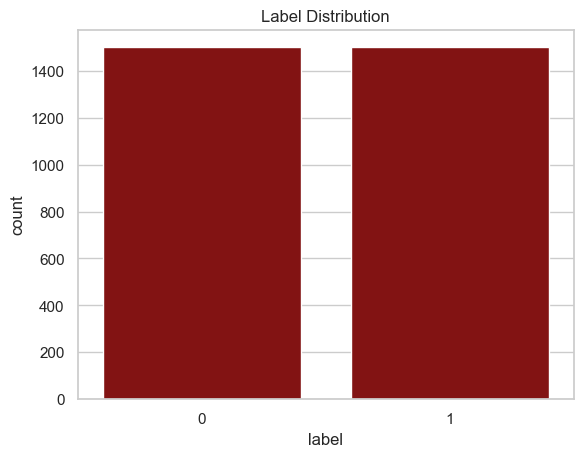

In [5]:
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

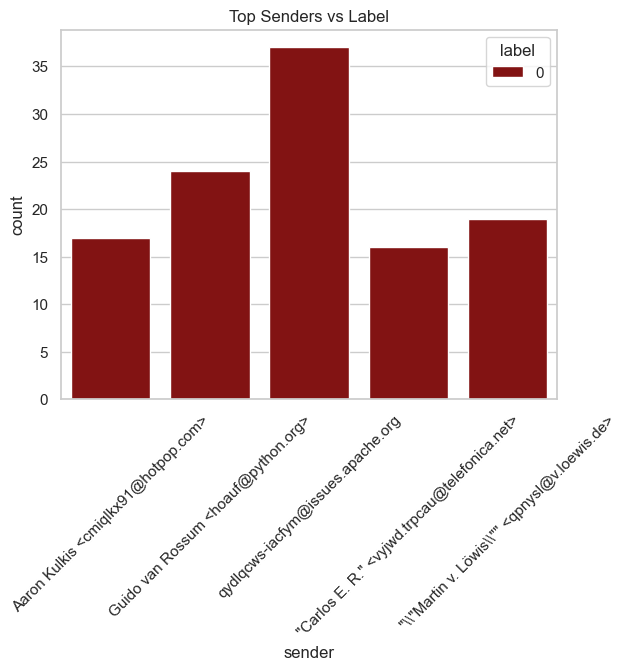

In [6]:
top = df['sender'].value_counts().head(5).index
sns.countplot(data=df[df['sender'].isin(top)], x='sender', hue='label')
plt.xticks(rotation=45)
plt.title("Top Senders vs Label")
plt.show()

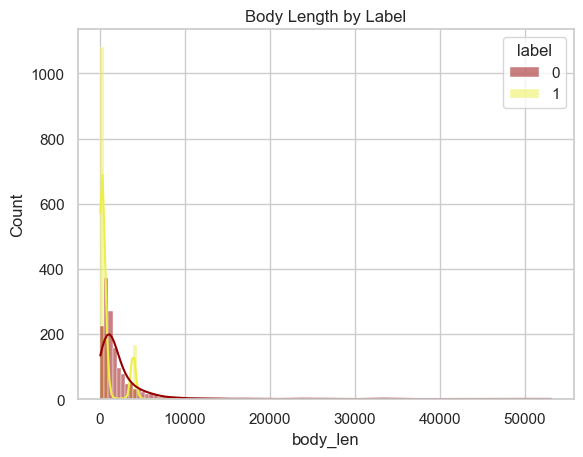

In [7]:
df['body_len'] = df['body'].astype(str).apply(len)

sns.histplot(data=df, x='body_len', hue='label', kde=True)
plt.title("Body Length by Label")
plt.show()

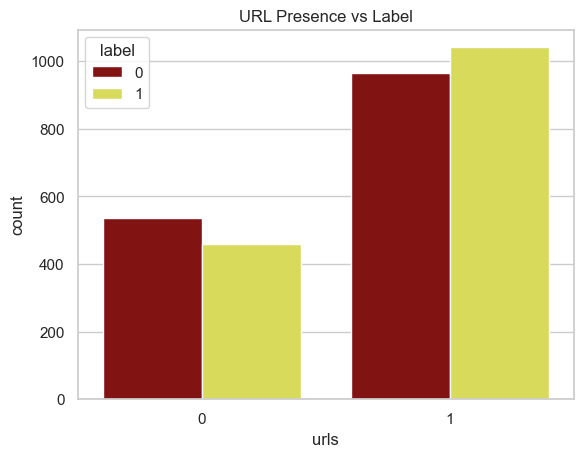

In [8]:
sns.countplot(x='urls', hue='label', data=df)
plt.title("URL Presence vs Label")
plt.show()

# 4. PreProcessing 

In [9]:
df = df.dropna()

In [10]:
#Preserve structure

df['text'] = "SUBJECT: " + df['subject'] + " BODY: " + df['body']

In [11]:
# Sender domain feature
df['sender_domain'] = df['sender'].str.extract(r'@(.+)')
df['sender_domain'] = df['sender_domain'].fillna('unknown')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2961 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sender         2961 non-null   object
 1   receiver       2961 non-null   object
 2   date           2961 non-null   object
 3   subject        2961 non-null   object
 4   body           2961 non-null   object
 5   label          2961 non-null   int64 
 6   urls           2961 non-null   int64 
 7   body_len       2961 non-null   int64 
 8   text           2961 non-null   object
 9   sender_domain  2961 non-null   object
dtypes: int64(3), object(7)
memory usage: 254.5+ KB


In [13]:
#5. Pipelines

In [14]:
X = df.drop(columns=['label', 'sender', 'subject', 'body','receiver','date'])
Y = df['label']

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2961 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   urls           2961 non-null   int64 
 1   body_len       2961 non-null   int64 
 2   text           2961 non-null   object
 3   sender_domain  2961 non-null   object
dtypes: int64(2), object(2)
memory usage: 115.7+ KB


In [15]:
# Column groups

text_col = 'text'
num_cols = ['urls', 'body_len']
cat_cols = ['sender_domain']

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), text_col),
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 6.Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [19]:
from sklearn.metrics import classification_report, accuracy_score

pipeline.fit(X_train, Y_train)

y_pred = pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Accuracy: 0.9780775716694773
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       293
           1       0.97      0.98      0.98       300

    accuracy                           0.98       593
   macro avg       0.98      0.98      0.98       593
weighted avg       0.98      0.98      0.98       593



# 7. Save the trained model

In [20]:
import pickle

with open("models/best_model.pkl", "wb") as file:  #
    pickle.dump(pipeline,file)

# 8. Saving the Package Version

In [21]:
import pkg_resources

# List of the packages you know you're using
required_packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'ipykernel',
]

requirements = []

for package in required_packages:
    try:
        version = pkg_resources.get_distribution(package).version
        requirements.append(f"{package}=={version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package {package} not found in the environment.")

#requirements to a file
with open('requirements.txt', 'w') as f:
    for line in requirements:
        f.write(line + '\n')

/var/folders/s3/7_ps073573349p4rwxh_fxzr0000gn/T/ipykernel_13377/116971148.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
